Notebook to illustrate the eliminate background spectrum (EBS) model. 

Please run the preproc_teflon.py script first.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from vebir.ebs import EBS
from vebir.veb import VEB, veb_pb_elbo
from vebir.pca import pca, loo_pca

In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

In [3]:
with open(PREPROC_DIR  / 'blanks_dict.pkl', 'rb') as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR  / "raw_spectra_dict.pkl", 'rb') as file:
    raw_spectra_dict = pickle.load(file) 

In [4]:
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)
Y = np.array(raw_spectra_dict["12-Tricosanone"]["raw"])

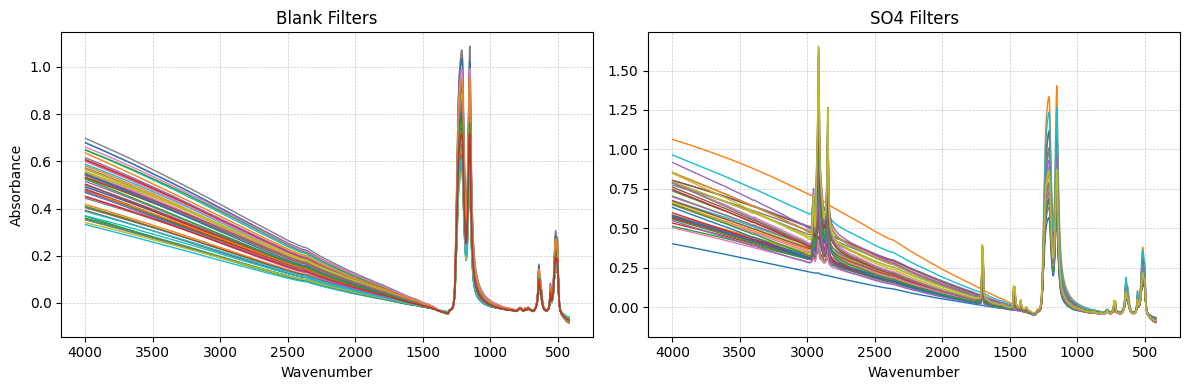

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  

for i in range(Z.shape[0]):
    axs[0].plot(wn,Z[i,:], linewidth=1)
axs[0].set_xlabel("Wavenumber")
axs[0].set_ylabel("Absorbance")    
axs[0].invert_xaxis()
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0].set_title("Blank Filters")

for i in range(Y.shape[0]):
    axs[1].plot(wn,Y[i,:], linewidth=1)
axs[1].set_xlabel("Wavenumber")   
axs[1].invert_xaxis()
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
axs[1].set_title("SO4 Filters")

plt.tight_layout()
plt.show()

In [6]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
y = Y[0,:]

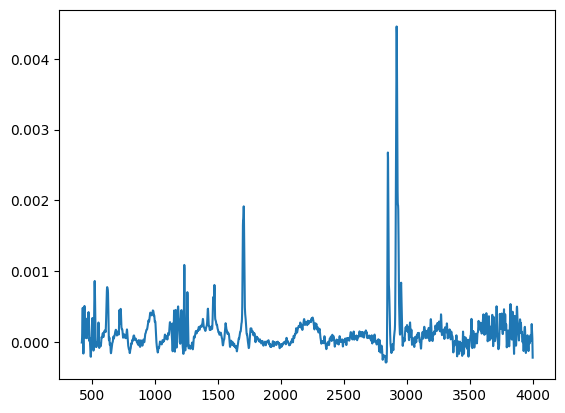

In [7]:
mod = EBS(loss="ALS")
mod.fit(y,mu,W)
plt.plot(wn,mod.absorbance)

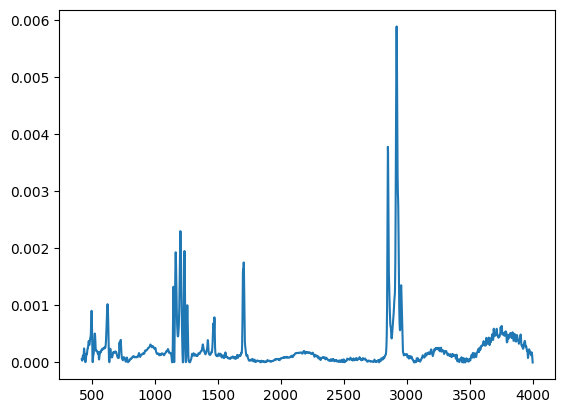

In [8]:
mod = VEB(c=W.shape[1],loss="ALS")
mod.fit(y,mu,W)
mod.map(y,mu,W)
plt.plot(wn,mod.absorbance)

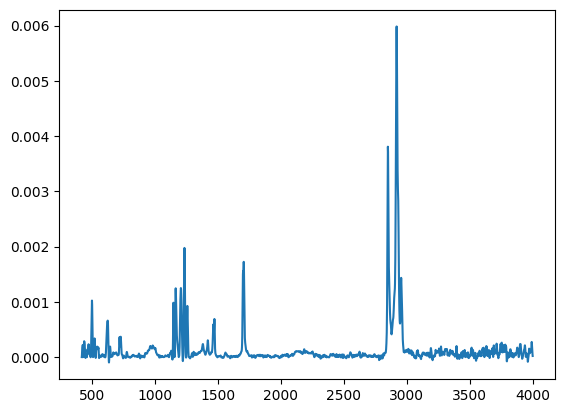

In [9]:
mod = EBS(loss="PB")
mod.fit(y,mu,W)
plt.plot(wn,mod.absorbance)

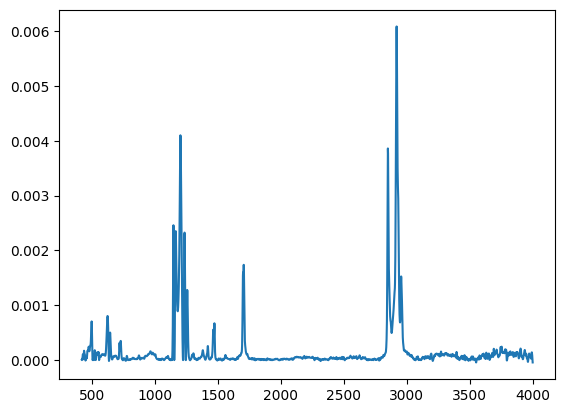

In [16]:
mod = VEB(c=W.shape[1])
mod.fit(y,mu,W)
mod.map(y,mu,W)
plt.plot(wn,mod.absorbance)